In [2]:
import json
import pandas as pd
from pathlib import Path


In [6]:
def load_multiple_json_objects(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read().strip()

    decoder = json.JSONDecoder()
    idx = 0
    objects = []

    while idx < len(content):
        # salta spazi bianchi
        while idx < len(content) and content[idx].isspace():
            idx += 1

        if idx >= len(content):
            break

        obj, end = decoder.raw_decode(content, idx)
        objects.append(obj)
        idx = end

    return objects
    

In [10]:
test_file = Path(r"C:\Users\a.genua\OneDrive - Scuola Superiore Sant'Anna\PROGETTI\Progetti in corso\Articoli in corso\RA-L_&_Sanseverino\FlightSimulator\SUB6\HIGH_MIS_SUB6\Test_PS_0_FlightSimulator_2026-02-25_16-10-43.txt")

objs = load_multiple_json_objects(test_file)

print("Numero oggetti JSON trovati:", len(objs))
print("Tipo primo oggetto:", type(objs[0]))
print("Primo oggetto:")
print(objs[0])

Numero oggetti JSON trovati: 51120
Tipo primo oggetto: <class 'dict'>
Primo oggetto:
{'HandStatus': None, 'FingersOpenClose': None, 'FingersLoadCell': None, 'DriversPWM': None, 'WristPronoSupination': 0.04818151, 'WristDevUlnRad': 0.0171251968, 'WristFlexExt': 0.3405124, 'VelocitiesJoints': [1.77635684e-15, -1.80262323e-05, -1.568179e-05], 'AccelerationJoints': [-1.51461294e-28, 0.010530293, 0.008368223], 'VelocitiesEE': [1.42393292e-05, 1.77089987e-05, 7.38217e-06], 'AccelerationEE': [-0.00755528035, -0.0103461286, -0.00409751059], 'MotorCurrent': [-0.232803956, -0.008973385, -0.009133194], 'TotalMotorJointTorques': [-1.16109991, 0.0233684927, 2.51234451e-05], 'HumanMotorJointTorques': [0.0, 0.0, 0.0], 'HumanMotorEETorques': [0.0, 0.0, 0.0], 'HandlePress': 100.0, 'Timestamp': '2026-02-25 15:10:45.068', 'TargetID': 0, 'TargetPosition': [0.0, 0.215, 0.0], 'AirplanePosition': [4.701309, 0.5195718, -423.682037], 'DistanceFromTarget': 423.708221, 'Status': 9, 'Score': 0.0, 'AngleErrors': [

In [14]:
from pathlib import Path
import json
import pandas as pd

def load_multiple_json_objects(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read().strip()

    decoder = json.JSONDecoder()
    idx = 0
    objects = []

    while idx < len(content):
        while idx < len(content) and content[idx].isspace():
            idx += 1

        if idx >= len(content):
            break

        obj, end = decoder.raw_decode(content, idx)
        objects.append(obj)
        idx = end

    return objects

base_path = Path(r"C:\Users\a.genua\OneDrive - Scuola Superiore Sant'Anna\PROGETTI\Progetti in corso\Articoli in corso\RA-L_&_Sanseverino\FlightSimulator")

all_records = []

for sub_folder in base_path.glob("SUB*"):
    if not sub_folder.is_dir():
        continue

    subject = sub_folder.name

    for cond_folder in sub_folder.iterdir():
        if not cond_folder.is_dir():
            continue

        folder_name = cond_folder.name.upper()

        if "HIGH_MIS" in folder_name:
            condition = "HIGH"
        elif "LOW_MIS" in folder_name:
            condition = "LOW"
        elif "NOMINAL_POSITION" in folder_name:
            condition = "NOMINAL"
        else:
            continue

        target_files = list(cond_folder.glob("*_targets.txt"))

        for target_file in target_files:
            main_file = target_file.with_name(target_file.name.replace("_targets.txt", ".txt"))

            if not main_file.exists():
                print(f"Main file non trovato per {target_file.name}")
                continue

            try:
                with open(target_file, "r", encoding="utf-8") as f:
                    targets_data = json.load(f)
            except Exception as e:
                print(f"Errore targets {target_file}: {e}")
                continue

            try:
                main_data_list = load_multiple_json_objects(main_file)
            except Exception as e:
                print(f"Errore main {main_file}: {e}")
                continue

            all_records.append({
                "subject": subject,
                "condition": condition,
                "folder": cond_folder.name,
                "main_file": main_file.name,
                "target_file": target_file.name,
                "targets_data": targets_data,
                "main_data_list": main_data_list
            })

df_pairs = pd.DataFrame(all_records)

print("Shape:", df_pairs.shape)
if not df_pairs.empty:
    print(df_pairs[["subject", "condition", "main_file", "target_file"]].head())
else:
    print("df_pairs è ancora vuoto")

Shape: (18, 7)
  subject condition                                          main_file  \
0    SUB1      HIGH  Test_PS_0_FlightSimulator_2026-02-23_14-04-41.txt   
1    SUB1       LOW  Test_PS_0_FlightSimulator_2026-02-23_15-31-35.txt   
2    SUB1   NOMINAL  Test_PS_0_FlightSimulator_2026-02-23_13-03-22.txt   
3    SUB2      HIGH  Test_PS_0_FlightSimulator_2026-02-23_17-00-10.txt   
4    SUB2       LOW  Test_PS_0_FlightSimulator_2026-02-23_16-45-48.txt   

                                         target_file  
0  Test_PS_0_FlightSimulator_2026-02-23_14-04-41_...  
1  Test_PS_0_FlightSimulator_2026-02-23_15-31-35_...  
2  Test_PS_0_FlightSimulator_2026-02-23_13-03-22_...  
3  Test_PS_0_FlightSimulator_2026-02-23_17-00-10_...  
4  Test_PS_0_FlightSimulator_2026-02-23_16-45-48_...  


In [16]:
print(df_pairs.shape)
print(df_pairs.head(2))

(18, 7)
  subject condition         folder  \
0    SUB1      HIGH  HIGH_MIS_SUB1   
1    SUB1       LOW   LOW_MIS_SUB1   

                                           main_file  \
0  Test_PS_0_FlightSimulator_2026-02-23_14-04-41.txt   
1  Test_PS_0_FlightSimulator_2026-02-23_15-31-35.txt   

                                         target_file  \
0  Test_PS_0_FlightSimulator_2026-02-23_14-04-41_...   
1  Test_PS_0_FlightSimulator_2026-02-23_15-31-35_...   

                                        targets_data  \
0  {'Targets': [{'WaypointIndex': 0, 'Position': ...   
1  {'Targets': [{'WaypointIndex': 0, 'Position': ...   

                                      main_data_list  
0  [{'HandStatus': None, 'FingersOpenClose': None...  
1  [{'HandStatus': None, 'FingersOpenClose': None...  


In [17]:
example_targets = df_pairs.iloc[0]["targets_data"]["Targets"]
example_main = df_pairs.iloc[0]["main_data_list"]

print("Numero target nel file targets:", len(example_targets))
print("Numero oggetti nel main file:", len(example_main))
print("Primo target:", example_targets[0])
print("Primo sample main:", example_main[0])

Numero target nel file targets: 484
Numero oggetti nel main file: 51267
Primo target: {'WaypointIndex': 0, 'Position': {'x': 0.0, 'y': 0.2150000035762787, 'z': 0.0}, 'Color': 3}
Primo sample main: {'HandStatus': None, 'FingersOpenClose': None, 'FingersLoadCell': None, 'DriversPWM': None, 'WristPronoSupination': -0.0316817537, 'WristDevUlnRad': 0.00737894559, 'WristFlexExt': 0.26351276, 'VelocitiesJoints': [-2.220446e-15, 0.001831697, 0.00183169625], 'AccelerationJoints': [1.51461294e-28, -0.08420004, -0.08419853], 'VelocitiesEE': [-0.00181931106, -0.0016624867, -0.00079779065], 'AccelerationEE': [0.08363027, 0.07642244, 0.03666917], 'MotorCurrent': [-0.244468525, -0.008453671, -0.009419082], 'TotalMotorJointTorques': [-1.21927655, 0.0230563916, -0.00101767282], 'HumanMotorJointTorques': [0.0, 0.0, 0.0], 'HumanMotorEETorques': [0.0, 0.0, 0.0], 'HandlePress': 0.0, 'Timestamp': '2026-02-23 13:04:42.555', 'TargetID': 0, 'TargetPosition': [0.0, 0.215, 0.0], 'AirplanePosition': [4.69820261, 

In [18]:
expanded_rows = []

for _, row in df_pairs.iterrows():
    subject = row["subject"]
    condition = row["condition"]
    folder = row["folder"]
    main_file = row["main_file"]

    targets_list = row["targets_data"].get("Targets", [])
    main_list = row["main_data_list"]

    for sample_idx, sample in enumerate(main_list):
        target_id = sample.get("TargetID")

        target_info = {}
        if isinstance(target_id, int) and 0 <= target_id < len(targets_list):
            target_info = targets_list[target_id]

        expanded_rows.append({
            "subject": subject,
            "condition": condition,
            "folder": folder,
            "main_file": main_file,
            "sample_idx": sample_idx,
            "timestamp": sample.get("Timestamp"),
            "target_id": target_id,
            "target_waypoint": target_info.get("WaypointIndex"),
            "target_color_id": target_info.get("Color"),
            "target_x": target_info.get("Position", {}).get("x") if target_info else None,
            "target_y": target_info.get("Position", {}).get("y") if target_info else None,
            "target_z": target_info.get("Position", {}).get("z") if target_info else None,
            "airplane_x": sample.get("AirplanePosition", [None, None, None])[0] if sample.get("AirplanePosition") else None,
            "airplane_y": sample.get("AirplanePosition", [None, None, None])[1] if sample.get("AirplanePosition") else None,
            "airplane_z": sample.get("AirplanePosition", [None, None, None])[2] if sample.get("AirplanePosition") else None,
            "distance_from_target": sample.get("DistanceFromTarget"),
            "status": sample.get("Status"),
            "score": sample.get("Score"),
            "handle_press": sample.get("HandlePress"),
        })

df_log = pd.DataFrame(expanded_rows)

print(df_log.shape)
print(df_log.head())

(923204, 19)
  subject condition         folder  \
0    SUB1      HIGH  HIGH_MIS_SUB1   
1    SUB1      HIGH  HIGH_MIS_SUB1   
2    SUB1      HIGH  HIGH_MIS_SUB1   
3    SUB1      HIGH  HIGH_MIS_SUB1   
4    SUB1      HIGH  HIGH_MIS_SUB1   

                                           main_file  sample_idx  \
0  Test_PS_0_FlightSimulator_2026-02-23_14-04-41.txt           0   
1  Test_PS_0_FlightSimulator_2026-02-23_14-04-41.txt           1   
2  Test_PS_0_FlightSimulator_2026-02-23_14-04-41.txt           2   
3  Test_PS_0_FlightSimulator_2026-02-23_14-04-41.txt           3   
4  Test_PS_0_FlightSimulator_2026-02-23_14-04-41.txt           4   

                 timestamp  target_id  target_waypoint  target_color_id  \
0  2026-02-23 13:04:42.555          0                0                3   
1  2026-02-23 13:04:42.579          0                0                3   
2  2026-02-23 13:04:42.586          0                0                3   
3  2026-02-23 13:04:42.592          0            

In [21]:
condition_order = {"NOMINAL": 0, "LOW": 1, "HIGH": 2}

df_log["condition_order"] = df_log["condition"].map(condition_order)

df_log = df_log.sort_values(
    by=["subject", "condition_order", "sample_idx"],
    ascending=[True, True, True]
).reset_index(drop=True)

df_log = df_log.drop(columns="condition_order")

print(df_log.head(200))

    subject condition                 folder  \
0      SUB1   NOMINAL  NOMINAL_POSITION_SUB1   
1      SUB1   NOMINAL  NOMINAL_POSITION_SUB1   
2      SUB1   NOMINAL  NOMINAL_POSITION_SUB1   
3      SUB1   NOMINAL  NOMINAL_POSITION_SUB1   
4      SUB1   NOMINAL  NOMINAL_POSITION_SUB1   
..      ...       ...                    ...   
195    SUB1   NOMINAL  NOMINAL_POSITION_SUB1   
196    SUB1   NOMINAL  NOMINAL_POSITION_SUB1   
197    SUB1   NOMINAL  NOMINAL_POSITION_SUB1   
198    SUB1   NOMINAL  NOMINAL_POSITION_SUB1   
199    SUB1   NOMINAL  NOMINAL_POSITION_SUB1   

                                             main_file  sample_idx  \
0    Test_PS_0_FlightSimulator_2026-02-23_13-03-22.txt           0   
1    Test_PS_0_FlightSimulator_2026-02-23_13-03-22.txt           1   
2    Test_PS_0_FlightSimulator_2026-02-23_13-03-22.txt           2   
3    Test_PS_0_FlightSimulator_2026-02-23_13-03-22.txt           3   
4    Test_PS_0_FlightSimulator_2026-02-23_13-03-22.txt           4   
.. 

In [22]:
color_map = {
    0: "color_0",
    1: "color_1",
    2: "color_2",
    3: "color_3",
    4: "color_4",
    5: "color_5",
}

df_log["target_color_name"] = df_log["target_color_id"].map(color_map)

print(df_log[["subject", "condition", "sample_idx", "target_id", "target_color_id", "target_color_name"]].head(20))

   subject condition  sample_idx  target_id  target_color_id target_color_name
0     SUB1   NOMINAL           0          0                1           color_1
1     SUB1   NOMINAL           1          0                1           color_1
2     SUB1   NOMINAL           2          0                1           color_1
3     SUB1   NOMINAL           3          0                1           color_1
4     SUB1   NOMINAL           4          0                1           color_1
5     SUB1   NOMINAL           5          0                1           color_1
6     SUB1   NOMINAL           6          0                1           color_1
7     SUB1   NOMINAL           7          0                1           color_1
8     SUB1   NOMINAL           8          0                1           color_1
9     SUB1   NOMINAL           9          0                1           color_1
10    SUB1   NOMINAL          10          0                1           color_1
11    SUB1   NOMINAL          11          0         

In [23]:
df_events = df_log.loc[
    df_log["target_id"].ne(df_log["target_id"].shift())
].copy()

df_events["trial_progressive"] = df_events.groupby(["subject", "condition"]).cumcount() + 1

print(df_events.shape)
print(df_events[[
    "subject", "condition", "trial_progressive",
    "timestamp", "target_id", "target_waypoint",
    "target_color_id", "target_color_name"
]].head(30))

(1664, 21)
      subject condition  trial_progressive                timestamp  \
0        SUB1   NOMINAL                  1  2026-02-23 12:03:24.211   
465      SUB1   NOMINAL                  2  2026-02-23 12:03:29.625   
1091     SUB1   NOMINAL                  3  2026-02-23 12:03:36.947   
1678     SUB1   NOMINAL                  4  2026-02-23 12:03:43.773   
2340     SUB1   NOMINAL                  5  2026-02-23 12:03:51.488   
2792     SUB1   NOMINAL                  6  2026-02-23 12:03:56.805   
3412     SUB1   NOMINAL                  7  2026-02-23 12:04:03.984   
3858     SUB1   NOMINAL                  8  2026-02-23 12:04:09.152   
4273     SUB1   NOMINAL                  9  2026-02-23 12:04:13.973   
4657     SUB1   NOMINAL                 10  2026-02-23 12:04:18.467   
5035     SUB1   NOMINAL                 11  2026-02-23 12:04:22.836   
5289     SUB1   NOMINAL                 12  2026-02-23 12:04:25.834   
5545     SUB1   NOMINAL                 13  2026-02-23 12:04:28.92

In [24]:
print(df_log[["subject", "condition"]].drop_duplicates().sort_values(["subject", "condition"]))


       subject condition
103074    SUB1      HIGH
51429     SUB1       LOW
0         SUB1   NOMINAL
262482    SUB2      HIGH
210363    SUB2       LOW
154341    SUB2   NOMINAL
415684    SUB3      HIGH
365053    SUB3       LOW
313675    SUB3   NOMINAL
569192    SUB4      HIGH
519500    SUB4       LOW
468359    SUB4   NOMINAL
720133    SUB5      HIGH
670858    SUB5       LOW
620626    SUB5   NOMINAL
872084    SUB6      HIGH
820821    SUB6       LOW
769752    SUB6   NOMINAL


In [26]:
df_pairs[
    (df_pairs["subject"] == "SUB1") & 
    (df_pairs["condition"] == "NOMINAL")
][["subject", "condition", "folder", "main_file", "target_file"]]

,subject,condition,folder,main_file,target_file
2,SUB1,NOMINAL,NOMINAL_POSITION_SUB1,Test_PS_0_FlightSimulator_2026-02-23_13-03-22.txt,Test_PS_0_FlightSimulator_2026-02-23_13-03-22_...


In [27]:
row_nominal_sub1 = df_pairs[
    (df_pairs["subject"] == "SUB1") & 
    (df_pairs["condition"] == "NOMINAL")
].iloc[0]

print("Folder:", row_nominal_sub1["folder"])
print("Main file:", row_nominal_sub1["main_file"])
print("Target file:", row_nominal_sub1["target_file"])
print("Numero targets:", len(row_nominal_sub1["targets_data"].get("Targets", [])))
print("Numero sample main:", len(row_nominal_sub1["main_data_list"]))

Folder: NOMINAL_POSITION_SUB1
Main file: Test_PS_0_FlightSimulator_2026-02-23_13-03-22.txt
Target file: Test_PS_0_FlightSimulator_2026-02-23_13-03-22_targets.txt
Numero targets: 484
Numero sample main: 51429


In [28]:
expanded_rows = []

for _, row in df_pairs.iterrows():
    subject = row["subject"]
    condition = row["condition"]
    folder = row["folder"]
    main_file = row["main_file"]

    targets_list = row["targets_data"].get("Targets", [])
    main_list = row["main_data_list"]

    print(f"{subject} | {condition} | n_targets={len(targets_list)} | n_samples={len(main_list)}")

    for sample_idx, sample in enumerate(main_list):
        target_id = sample.get("TargetID")

        target_info = {}
        if isinstance(target_id, int) and 0 <= target_id < len(targets_list):
            target_info = targets_list[target_id]

        airplane_pos = sample.get("AirplanePosition")
        if isinstance(airplane_pos, list) and len(airplane_pos) >= 3:
            airplane_x, airplane_y, airplane_z = airplane_pos[:3]
        else:
            airplane_x, airplane_y, airplane_z = None, None, None

        expanded_rows.append({
            "subject": subject,
            "condition": condition,
            "folder": folder,
            "main_file": main_file,
            "sample_idx": sample_idx,
            "timestamp": sample.get("Timestamp"),
            "target_id": target_id,
            "target_waypoint": target_info.get("WaypointIndex"),
            "target_color_id": target_info.get("Color"),
            "target_x": target_info.get("Position", {}).get("x") if target_info else None,
            "target_y": target_info.get("Position", {}).get("y") if target_info else None,
            "target_z": target_info.get("Position", {}).get("z") if target_info else None,
            "airplane_x": airplane_x,
            "airplane_y": airplane_y,
            "airplane_z": airplane_z,
            "distance_from_target": sample.get("DistanceFromTarget"),
            "status": sample.get("Status"),
            "score": sample.get("Score"),
            "handle_press": sample.get("HandlePress"),
        })

df_log = pd.DataFrame(expanded_rows)

print("\nConteggi finali:")
print(df_log.groupby(["subject", "condition"]).size())

SUB1 | HIGH | n_targets=484 | n_samples=51267
SUB1 | LOW | n_targets=484 | n_samples=51645
SUB1 | NOMINAL | n_targets=484 | n_samples=51429
SUB2 | HIGH | n_targets=484 | n_samples=51193
SUB2 | LOW | n_targets=484 | n_samples=52119
SUB2 | NOMINAL | n_targets=484 | n_samples=56022
SUB3 | HIGH | n_targets=484 | n_samples=52675
SUB3 | LOW | n_targets=484 | n_samples=50631
SUB3 | NOMINAL | n_targets=484 | n_samples=51378
SUB4 | HIGH | n_targets=484 | n_samples=51434
SUB4 | LOW | n_targets=484 | n_samples=49692
SUB4 | NOMINAL | n_targets=484 | n_samples=51141
SUB5 | HIGH | n_targets=484 | n_samples=49619
SUB5 | LOW | n_targets=484 | n_samples=49275
SUB5 | NOMINAL | n_targets=484 | n_samples=50232
SUB6 | HIGH | n_targets=484 | n_samples=51120
SUB6 | LOW | n_targets=484 | n_samples=51263
SUB6 | NOMINAL | n_targets=484 | n_samples=51069

Conteggi finali:
subject  condition
SUB1     HIGH         51267
         LOW          51645
         NOMINAL      51429
SUB2     HIGH         51193
         LO

In [30]:
color_map = {
    0: "Green",
    1: "Red",
    2: "Yellow",
    3: "Blue",
    4: "Black",
}

df_log["target_color_name"] = df_log["target_color_id"].map(color_map)

In [31]:
df_events["target_color_name"] = df_events["target_color_id"].map(color_map)

In [32]:
df_events = df_events[[
    "subject",
    "condition",
    "trial_progressive",
    "timestamp",
    "target_id",
    "target_waypoint",
    "target_color_id",
    "target_color_name"
]].copy()

print(df_events.head(20))
print(df_events["target_color_name"].value_counts())

     subject condition  trial_progressive                timestamp  target_id  \
0       SUB1   NOMINAL                  1  2026-02-23 12:03:24.211          0   
465     SUB1   NOMINAL                  2  2026-02-23 12:03:29.625          1   
1091    SUB1   NOMINAL                  3  2026-02-23 12:03:36.947          2   
1678    SUB1   NOMINAL                  4  2026-02-23 12:03:43.773          3   
2340    SUB1   NOMINAL                  5  2026-02-23 12:03:51.488          4   
2792    SUB1   NOMINAL                  6  2026-02-23 12:03:56.805          5   
3412    SUB1   NOMINAL                  7  2026-02-23 12:04:03.984          6   
3858    SUB1   NOMINAL                  8  2026-02-23 12:04:09.152          7   
4273    SUB1   NOMINAL                  9  2026-02-23 12:04:13.973          8   
4657    SUB1   NOMINAL                 10  2026-02-23 12:04:18.467          9   
5035    SUB1   NOMINAL                 11  2026-02-23 12:04:22.836         10   
5289    SUB1   NOMINAL      

In [37]:
df_events = df_log.loc[
    df_log.groupby(["subject", "condition"])["target_id"]
          .transform(lambda s: s.ne(s.shift()))
].copy()

# PRIMA crea trial_progressive
df_events["trial_progressive"] = (
    df_events.groupby(["subject", "condition"]).cumcount() + 1
)

# POI ordina
df_events = df_events.sort_values(
    ["subject", "condition", "trial_progressive"]
).reset_index(drop=True)

In [38]:
print(df_events.columns)


Index(['subject', 'condition', 'folder', 'main_file', 'sample_idx',
       'timestamp', 'target_id', 'target_waypoint', 'target_color_id',
       'target_x', 'target_y', 'target_z', 'airplane_x', 'airplane_y',
       'airplane_z', 'distance_from_target', 'status', 'score', 'handle_press',
       'target_color_name', 'trial_progressive'],
      dtype='object')


In [39]:
df_events["color_minus_2"] = (
    df_events.groupby(["subject", "condition"])["target_color_name"].shift(2)
)

df_events["is_black"] = df_events["target_color_name"] == "Black"

df_2back = df_events[df_events["is_black"]].copy()

df_2back["black_trial_index"] = (
    df_2back.groupby(["subject", "condition"]).cumcount() + 1
)

df_2back["correct_response"] = df_2back["color_minus_2"]

In [41]:
excel_path = base_path / "2-BACK-TASK-analisi.xlsx"
df_excel = pd.read_excel(excel_path, header=None)

print(df_excel.shape)
print(df_excel.head(8))

(32, 31)
        0                        1       2       3                     4   \
0  SUBJECT  1 (Cristian Camardella)     NaN     NaN  2 (Alessandro Genua)   
1      NaN                  NOMINAL     LOW    HIGH                   LOW   
2      NaN                    ROSSO     BLU   ROSSO                GIALLO   
3      NaN                    ROSSO  GIALLO   VERDE                   BLU   
4      NaN                   GIALLO   ROSSO   ROSSO                GIALLO   
5      NaN                    ROSSO   ROSSO   VERDE                GIALLO   
6      NaN                    VERDE     BLU   VERDE                   BLU   
7      NaN                   GIALLO   ROSSO  GIALLO                 VERDE   

       5        6                   7      8      9   ...     21  \
0     NaN      NaN  3 (Federica Serra)    NaN    NaN  ...    NaN   
1    HIGH  NOMINAL             NOMINAL    LOW   HIGH  ...    LOW   
2   ROSSO    VERDE                 BLU  VERDE  VERDE  ...    BLU   
3     BLU    VERDE       

In [42]:
subjects = ["SUB1", "SUB2", "SUB3", "SUB4", "SUB5", "SUB6", "SUB7", "SUB8", "SUB9", "SUB10"]
conditions = ["NOMINAL", "LOW", "HIGH"]

records = []

# le risposte partono dalla riga 2 (0-based)
data_rows = df_excel.iloc[2:, :]

for i, subject in enumerate(subjects):
    for j, condition in enumerate(conditions):
        col_idx = i * 3 + j

        if col_idx >= data_rows.shape[1]:
            continue

        col_data = data_rows.iloc[:, col_idx].dropna()

        for k, value in enumerate(col_data):
            value_str = str(value).strip().upper()

            if value_str == "":
                continue

            records.append({
                "subject": subject,
                "condition": condition,
                "black_trial_index": k + 1,
                "response_raw": value_str
            })

df_responses = pd.DataFrame(records)

print(df_responses.head(20))
print(df_responses.groupby(["subject", "condition"]).size())

   subject condition  black_trial_index response_raw
0     SUB1       LOW                  1        ROSSO
1     SUB1       LOW                  2        ROSSO
2     SUB1       LOW                  3       GIALLO
3     SUB1       LOW                  4        ROSSO
4     SUB1       LOW                  5        VERDE
5     SUB1       LOW                  6       GIALLO
6     SUB1       LOW                  7          BLU
7     SUB1       LOW                  8       GIALLO
8     SUB1       LOW                  9       GIALLO
9     SUB1       LOW                 10        ROSSO
10    SUB1       LOW                 11        ROSSO
11    SUB1       LOW                 12        ROSSO
12    SUB1       LOW                 13        VERDE
13    SUB1       LOW                 14          BLU
14    SUB1       LOW                 15       GIALLO
15    SUB1       LOW                 16       GIALLO
16    SUB1       LOW                 17        VERDE
17    SUB1       LOW                 18       

In [43]:
color_translation = {
    "ROSSO": "Red",
    "BLU": "Blue",
    "VERDE": "Green",
    "GIALLO": "Yellow",
    "YELLOW": "Yellow",
    "GREEN": "Green",
    "RED": "Red",
    "BLUE": "Blue",
    "BLACK": "Black",
    "FAIL": None
}

df_responses["response"] = df_responses["response_raw"].map(color_translation)

print(df_responses.head(20))

   subject condition  black_trial_index response_raw response
0     SUB1       LOW                  1        ROSSO      Red
1     SUB1       LOW                  2        ROSSO      Red
2     SUB1       LOW                  3       GIALLO   Yellow
3     SUB1       LOW                  4        ROSSO      Red
4     SUB1       LOW                  5        VERDE    Green
5     SUB1       LOW                  6       GIALLO   Yellow
6     SUB1       LOW                  7          BLU     Blue
7     SUB1       LOW                  8       GIALLO   Yellow
8     SUB1       LOW                  9       GIALLO   Yellow
9     SUB1       LOW                 10        ROSSO      Red
10    SUB1       LOW                 11        ROSSO      Red
11    SUB1       LOW                 12        ROSSO      Red
12    SUB1       LOW                 13        VERDE    Green
13    SUB1       LOW                 14          BLU     Blue
14    SUB1       LOW                 15       GIALLO   Yellow
15    SU

In [44]:
df_final = pd.merge(
    df_2back,
    df_responses,
    on=["subject", "condition", "black_trial_index"],
    how="left"
)

df_final["is_correct"] = df_final["correct_response"] == df_final["response"]

print(df_final[[
    "subject", "condition", "black_trial_index",
    "correct_response", "response", "is_correct"
]].head(30))

   subject condition  black_trial_index correct_response response  is_correct
0     SUB1      HIGH                  1              Red     Blue       False
1     SUB1      HIGH                  2              Red   Yellow       False
2     SUB1      HIGH                  3              Red      Red        True
3     SUB1      HIGH                  4            Green      Red       False
4     SUB1      HIGH                  5            Green     Blue       False
5     SUB1      HIGH                  6           Yellow      Red       False
6     SUB1      HIGH                  7           Yellow    Green       False
7     SUB1      HIGH                  8              Red      Red        True
8     SUB1      HIGH                  9              Red      Red        True
9     SUB1      HIGH                 10              Red     Blue       False
10    SUB1      HIGH                 11              Red   Yellow       False
11    SUB1      HIGH                 12              Red   Yello

In [45]:
print("Neri attesi:")
print(df_2back.groupby(["subject", "condition"]).size())

print("\nRisposte trovate in Excel:")
print(df_responses.groupby(["subject", "condition"]).size())

Neri attesi:
subject  condition
SUB1     HIGH         26
         LOW          26
         NOMINAL      27
SUB2     HIGH         14
         LOW          20
         NOMINAL      23
SUB3     HIGH         24
         LOW          29
         NOMINAL      17
SUB4     HIGH         18
         LOW          29
         NOMINAL      30
SUB5     HIGH         15
         LOW          16
         NOMINAL      14
SUB6     HIGH         24
         LOW          18
         NOMINAL      19
dtype: int64

Risposte trovate in Excel:
subject  condition
SUB1     HIGH         26
         LOW          27
SUB10    HIGH         27
         LOW          23
         NOMINAL      29
SUB2     HIGH         14
         LOW          20
         NOMINAL      28
SUB3     HIGH         29
         LOW          16
         NOMINAL      23
SUB4     HIGH         30
         LOW          17
         NOMINAL      24
SUB5     HIGH         16
         LOW          13
         NOMINAL      29
SUB6     HIGH         22
        

In [46]:
# Tieni solo i soggetti che hai davvero nei log
subjects_in_log = sorted(df_2back["subject"].unique())
df_responses = df_responses[df_responses["subject"].isin(subjects_in_log)].copy()

# Costruisci una versione del log allineata al numero di risposte Excel
aligned_log_parts = []

for (subj, cond), group_log in df_2back.groupby(["subject", "condition"]):
    group_log = group_log.sort_values("black_trial_index").copy()

    n_responses = len(
        df_responses[
            (df_responses["subject"] == subj) &
            (df_responses["condition"] == cond)
        ]
    )

    # tieni solo i primi N eventi black del log
    group_log = group_log.head(n_responses).copy()

    aligned_log_parts.append(group_log)

df_2back_aligned = pd.concat(aligned_log_parts, ignore_index=True)

print("Log allineato:")
print(df_2back_aligned.groupby(["subject", "condition"]).size())

print("\nRisposte Excel:")
print(df_responses.groupby(["subject", "condition"]).size())

Log allineato:
subject  condition
SUB1     HIGH         26
         LOW          26
SUB2     HIGH         14
         LOW          20
         NOMINAL      23
SUB3     HIGH         24
         LOW          16
         NOMINAL      17
SUB4     HIGH         18
         LOW          17
         NOMINAL      24
SUB5     HIGH         15
         LOW          13
         NOMINAL      14
SUB6     HIGH         22
         LOW          15
         NOMINAL      14
dtype: int64

Risposte Excel:
subject  condition
SUB1     HIGH         26
         LOW          27
SUB2     HIGH         14
         LOW          20
         NOMINAL      28
SUB3     HIGH         29
         LOW          16
         NOMINAL      23
SUB4     HIGH         30
         LOW          17
         NOMINAL      24
SUB5     HIGH         16
         LOW          13
         NOMINAL      29
SUB6     HIGH         22
         LOW          15
         NOMINAL      14
dtype: int64


In [47]:
counts_log = df_2back_aligned.groupby(["subject", "condition"]).size().rename("n_log")
counts_resp = df_responses.groupby(["subject", "condition"]).size().rename("n_resp")

check_counts = pd.concat([counts_log, counts_resp], axis=1)
print(check_counts)

                   n_log  n_resp
subject condition               
SUB1    HIGH          26      26
        LOW           26      27
SUB2    HIGH          14      14
        LOW           20      20
        NOMINAL       23      28
SUB3    HIGH          24      29
        LOW           16      16
        NOMINAL       17      23
SUB4    HIGH          18      30
        LOW           17      17
        NOMINAL       24      24
SUB5    HIGH          15      16
        LOW           13      13
        NOMINAL       14      29
SUB6    HIGH          22      22
        LOW           15      15
        NOMINAL       14      14


In [48]:
df_final = pd.merge(
    df_2back_aligned,
    df_responses,
    on=["subject", "condition", "black_trial_index"],
    how="left"
)

df_final["is_correct"] = df_final["correct_response"] == df_final["response"]

print(df_final[[
    "subject", "condition", "black_trial_index",
    "correct_response", "response", "is_correct"
]].head(30))

   subject condition  black_trial_index correct_response response  is_correct
0     SUB1      HIGH                  1              Red     Blue       False
1     SUB1      HIGH                  2              Red   Yellow       False
2     SUB1      HIGH                  3              Red      Red        True
3     SUB1      HIGH                  4            Green      Red       False
4     SUB1      HIGH                  5            Green     Blue       False
5     SUB1      HIGH                  6           Yellow      Red       False
6     SUB1      HIGH                  7           Yellow    Green       False
7     SUB1      HIGH                  8              Red      Red        True
8     SUB1      HIGH                  9              Red      Red        True
9     SUB1      HIGH                 10              Red     Blue       False
10    SUB1      HIGH                 11              Red   Yellow       False
11    SUB1      HIGH                 12              Red   Yello

In [49]:
subjects_6 = ["SUB1", "SUB2", "SUB3", "SUB4", "SUB5", "SUB6"]

df_2back_6 = df_2back[df_2back["subject"].isin(subjects_6)].copy()
df_responses_6 = df_responses[df_responses["subject"].isin(subjects_6)].copy()

In [50]:
aligned_log_parts = []

for (subj, cond), group_log in df_2back_6.groupby(["subject", "condition"]):
    group_log = group_log.sort_values("black_trial_index").copy()

    n_responses = len(
        df_responses_6[
            (df_responses_6["subject"] == subj) &
            (df_responses_6["condition"] == cond)
        ]
    )

    group_log = group_log.head(n_responses).copy()

    aligned_log_parts.append(group_log)

df_2back_aligned_6 = pd.concat(aligned_log_parts, ignore_index=True)

In [51]:
print("LOG:")
print(df_2back_aligned_6.groupby(["subject", "condition"]).size())

print("\nEXCEL:")
print(df_responses_6.groupby(["subject", "condition"]).size())

LOG:
subject  condition
SUB1     HIGH         26
         LOW          26
SUB2     HIGH         14
         LOW          20
         NOMINAL      23
SUB3     HIGH         24
         LOW          16
         NOMINAL      17
SUB4     HIGH         18
         LOW          17
         NOMINAL      24
SUB5     HIGH         15
         LOW          13
         NOMINAL      14
SUB6     HIGH         22
         LOW          15
         NOMINAL      14
dtype: int64

EXCEL:
subject  condition
SUB1     HIGH         26
         LOW          27
SUB2     HIGH         14
         LOW          20
         NOMINAL      28
SUB3     HIGH         29
         LOW          16
         NOMINAL      23
SUB4     HIGH         30
         LOW          17
         NOMINAL      24
SUB5     HIGH         16
         LOW          13
         NOMINAL      29
SUB6     HIGH         22
         LOW          15
         NOMINAL      14
dtype: int64


In [52]:
df_final_6 = pd.merge(
    df_2back_aligned_6,
    df_responses_6,
    on=["subject", "condition", "black_trial_index"],
    how="left"
)

In [53]:
df_final_6["is_correct"] = (
    df_final_6["correct_response"] == df_final_6["response"]
)

In [54]:
acc_subj = df_final_6.groupby(["subject", "condition"])["is_correct"].mean()

print(acc_subj)

subject  condition
SUB1     HIGH         0.153846
         LOW          0.153846
SUB2     HIGH         0.714286
         LOW          0.800000
         NOMINAL      0.217391
SUB3     HIGH         0.208333
         LOW          0.187500
         NOMINAL      0.294118
SUB4     HIGH         0.222222
         LOW          0.176471
         NOMINAL      0.125000
SUB5     HIGH         0.533333
         LOW          0.538462
         NOMINAL      0.285714
SUB6     HIGH         0.363636
         LOW          0.066667
         NOMINAL      0.285714
Name: is_correct, dtype: float64


In [55]:
acc_cond = df_final_6.groupby("condition")["is_correct"].mean()

print(acc_cond)

condition
HIGH       0.327731
LOW        0.317757
NOMINAL    0.228261
Name: is_correct, dtype: float64


In [56]:
acc_cond = df_final_6.groupby("condition")["is_correct"].mean()

print(acc_cond)

condition
HIGH       0.327731
LOW        0.317757
NOMINAL    0.228261
Name: is_correct, dtype: float64


In [57]:
acc_stats = df_final_6.groupby("condition")["is_correct"].agg(["mean", "std"])

print(acc_stats)

               mean       std
condition                    
HIGH       0.327731  0.471371
LOW        0.317757  0.467796
NOMINAL    0.228261  0.422011


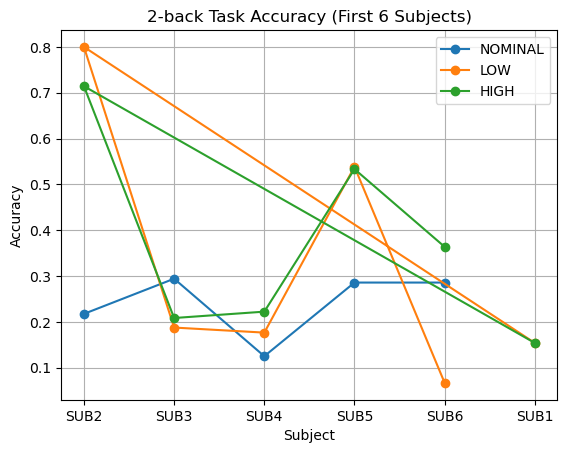

In [58]:
import matplotlib.pyplot as plt

acc_plot = df_final_6.groupby(["subject", "condition"])["is_correct"].mean().reset_index()

for cond in ["NOMINAL", "LOW", "HIGH"]:
    subset = acc_plot[acc_plot["condition"] == cond]
    plt.plot(subset["subject"], subset["is_correct"], marker='o', label=cond)

plt.ylabel("Accuracy")
plt.xlabel("Subject")
plt.title("2-back Task Accuracy (First 6 Subjects)")
plt.legend()
plt.grid()

plt.show()

In [59]:
df_final_6.groupby("condition")["is_correct"].mean()


condition
HIGH       0.327731
LOW        0.317757
NOMINAL    0.228261
Name: is_correct, dtype: float64

In [60]:
df_final_6.groupby("condition")["is_correct"].std()

condition
HIGH       0.471371
LOW        0.467796
NOMINAL    0.422011
Name: is_correct, dtype: float64

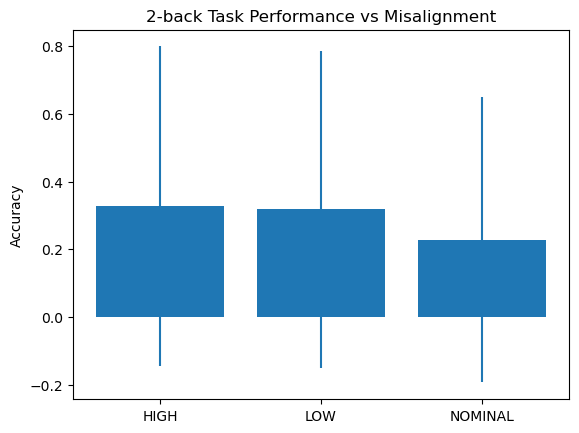

In [61]:
import matplotlib.pyplot as plt

stats = df_final_6.groupby("condition")["is_correct"].agg(["mean", "std"])

plt.bar(stats.index, stats["mean"])
plt.errorbar(stats.index, stats["mean"], yerr=stats["std"], fmt='none')

plt.ylabel("Accuracy")
plt.title("2-back Task Performance vs Misalignment")
plt.show()

In [62]:
df_diff = df_final_6.copy()

baseline = df_diff[df_diff["condition"] == "NOMINAL"][["subject", "is_correct"]]
baseline = baseline.groupby("subject").mean().rename(columns={"is_correct": "baseline"})

df_diff = df_diff.merge(baseline, on="subject")

df_diff["delta"] = df_diff["is_correct"] - df_diff["baseline"]

print(df_diff.groupby("condition")["delta"].mean())

condition
HIGH       1.298524e-01
LOW        1.335962e-01
NOMINAL    1.206764e-18
Name: delta, dtype: float64


In [64]:
variance = df_final_6.groupby("subject")["is_correct"].std()

print(variance)

subject
SUB1    0.364321
SUB2    0.502500
SUB3    0.423318
SUB4    0.378406
SUB5    0.503761
SUB6    0.440143
Name: is_correct, dtype: float64


In [65]:
ranking = (
    df_final_6.groupby(["subject", "condition"])["is_correct"]
    .mean()
    .groupby("subject")
    .rank(ascending=False)
)

print(ranking)

subject  condition
SUB1     HIGH         1.5
         LOW          1.5
SUB2     HIGH         2.0
         LOW          1.0
         NOMINAL      3.0
SUB3     HIGH         2.0
         LOW          3.0
         NOMINAL      1.0
SUB4     HIGH         1.0
         LOW          2.0
         NOMINAL      3.0
SUB5     HIGH         2.0
         LOW          1.0
         NOMINAL      3.0
SUB6     HIGH         1.0
         LOW          3.0
         NOMINAL      2.0
Name: is_correct, dtype: float64


In [63]:
best_per_subject = (
    df_final_6.groupby(["subject", "condition"])["is_correct"]
    .mean()
    .reset_index()
)

best = best_per_subject.loc[
    best_per_subject.groupby("subject")["is_correct"].idxmax()
]

print(best)

   subject condition  is_correct
0     SUB1      HIGH    0.153846
3     SUB2       LOW    0.800000
7     SUB3   NOMINAL    0.294118
8     SUB4      HIGH    0.222222
12    SUB5       LOW    0.538462
14    SUB6      HIGH    0.363636


In [66]:
best_counts = best.groupby("condition").size()

print(best_counts)


condition
HIGH       3
LOW        2
NOMINAL    1
dtype: int64


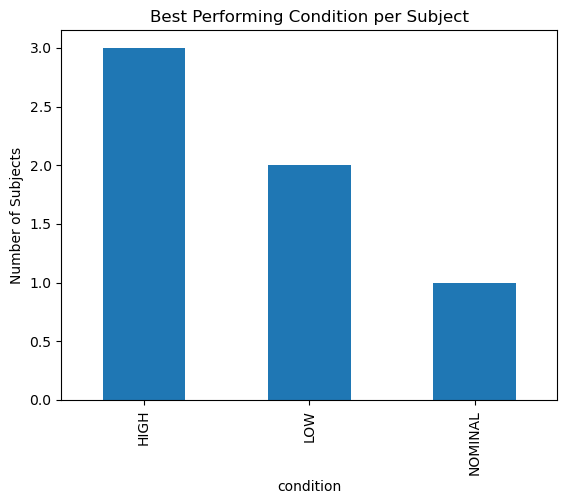

In [67]:
import matplotlib.pyplot as plt

best_counts.plot(kind="bar")

plt.ylabel("Number of Subjects")
plt.title("Best Performing Condition per Subject")

plt.show()